# Install

In [4]:
import subprocess, sys, os

FLAG = '/tmp/fre_installed.flag'
if not os.path.exists(FLAG):
    pkgs = [
        'numpy==1.24.4',
        'facenet-pytorch==2.5.3',
        'onnx>=1.14.0',
        'onnxruntime>=1.15.0',
        'seaborn>=0.12.0',
        'pyyaml>=6.0',
        'tensorboard>=2.13.0',
    ]
    for p in pkgs:
        print(f'Installing {p}...', end=' ', flush=True)
        r = subprocess.run([sys.executable,'-m','pip','install','-q',p],
                           capture_output=True, text=True)
        print('OK' if r.returncode==0 else f'GAGAL: {r.stderr[-100:]}')
    open(FLAG, 'w').close()
    print('\n== INSTALL SELESAI ==')
    print('Klik: Runtime -> Restart Runtime')
    print('Lalu jalankan mulai dari cell berikutnya')
else:
    print('Packages sudah terinstall.')

# Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
BASE_DIR = '/content/drive/MyDrive/Projek/face_recognition_ewallet'

In [5]:
import sys, os
sys.path.insert(0, BASE_DIR)
os.chdir(BASE_DIR)

from src.utils import load_config, resolve_paths, set_seed, setup_logging, get_device

cfg    = load_config('config/config.yaml')
cfg    = resolve_paths(cfg, BASE_DIR)
set_seed(cfg['project']['seed'])
device = get_device()
setup_logging(cfg['paths']['logs'], 'eda')

print(f"Setup selesai | device={device}")
print(f"Dataset  : {cfg['data']['dataset_root']}")
print(f"Processed: {cfg['data']['processed_dir']}")

⚠️  GPU tidak ditemukan — pakai CPU (training akan lambat)
Setup selesai | device=cpu
Dataset  : /content/drive/MyDrive/Projek/face_recognition_ewallet/data/raw/105_classes_pins_dataset
Processed: /content/drive/MyDrive/Projek/face_recognition_ewallet/data/processed


# Scan Dataset

In [6]:
from pathlib import Path
from collections import Counter
import numpy as np

dataset_root = Path(cfg['data']['dataset_root'])

if not dataset_root.exists():
    raise FileNotFoundError(
        f"Folder tidak ditemukan:\n  {dataset_root}\n"
        "Pastikan dataset sudah diekstrak ke path tersebut."
    )

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

class_counts = {}
for cls_dir in sorted(dataset_root.iterdir()):
    if not cls_dir.is_dir():
        continue
    name  = cls_dir.name[5:] if cls_dir.name.lower().startswith('pins_') else cls_dir.name
    n     = sum(1 for f in cls_dir.rglob('*') if f.suffix.lower() in IMG_EXTS)
    if n > 0:
        class_counts[name] = n

counts = sorted(class_counts.values())
print(f"Dataset    : {dataset_root.name}")
print(f"Kelas      : {len(counts)}")
print(f"Gambar     : {sum(counts):,}")
print(f"Min/kelas  : {min(counts)}")
print(f"Max/kelas  : {max(counts)}")
print(f"Rata-rata  : {np.mean(counts):.1f}")
print(f"Median     : {np.median(counts):.0f}")

Dataset    : 105_classes_pins_dataset
Kelas      : 105
Gambar     : 17,534
Min/kelas  : 86
Max/kelas  : 237
Rata-rata  : 167.0
Median     : 169


# Visualisasi Distribusi

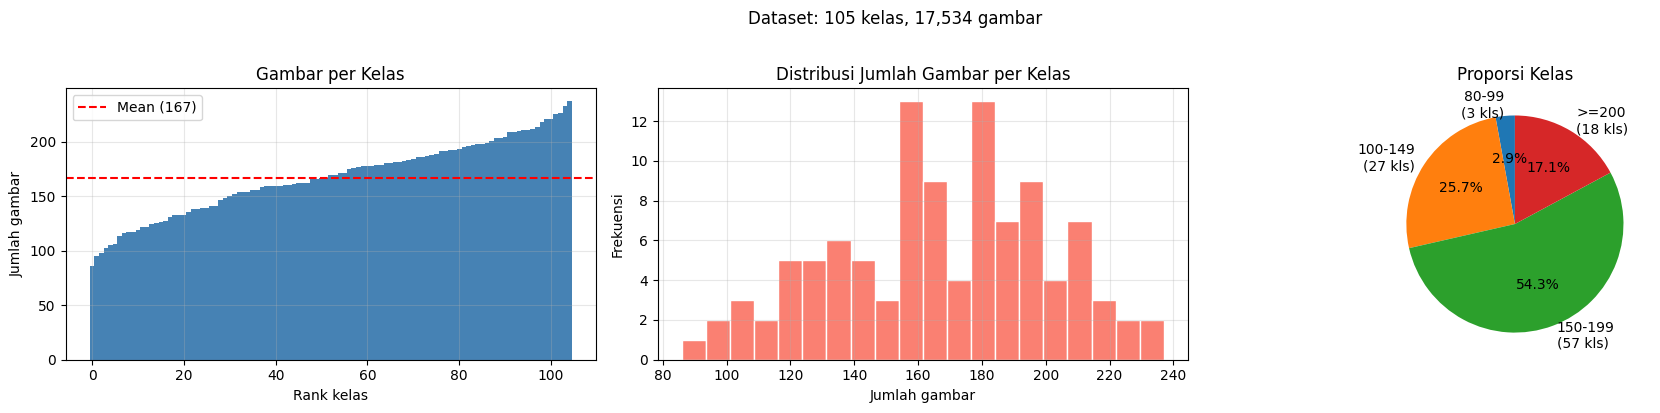

In [7]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from pathlib import Path

Path(cfg['paths']['results']).mkdir(parents=True, exist_ok=True)
counts_sorted = sorted(class_counts.values())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(range(len(counts_sorted)), counts_sorted, color='steelblue', width=1)
axes[0].axhline(np.mean(counts_sorted), color='red', linestyle='--',
                label=f"Mean ({np.mean(counts_sorted):.0f})")
axes[0].set_title('Gambar per Kelas')
axes[0].set_xlabel('Rank kelas')
axes[0].set_ylabel('Jumlah gambar')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(counts_sorted, bins=20, color='salmon', edgecolor='white')
axes[1].set_title('Distribusi Jumlah Gambar per Kelas')
axes[1].set_xlabel('Jumlah gambar')
axes[1].set_ylabel('Frekuensi')
axes[1].grid(True, alpha=0.3)

brackets = {'<80':0, '80-99':0, '100-149':0, '150-199':0, '>=200':0}
for c in counts_sorted:
    if   c < 80:  brackets['<80']     += 1
    elif c < 100: brackets['80-99']   += 1
    elif c < 150: brackets['100-149'] += 1
    elif c < 200: brackets['150-199'] += 1
    else:         brackets['>=200']   += 1

vals   = [v for v in brackets.values() if v > 0]
labels = [f"{k}\n({v} kls)" for k, v in brackets.items() if v > 0]
axes[2].pie(vals, labels=labels, autopct='%1.1f%%', startangle=90)
axes[2].set_title('Proporsi Kelas')

plt.suptitle(f"Dataset: {len(counts_sorted)} kelas, {sum(counts_sorted):,} gambar", y=1.02)
plt.tight_layout()
plt.savefig(f"{cfg['paths']['results']}/eda_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# Preview Gambar Raw

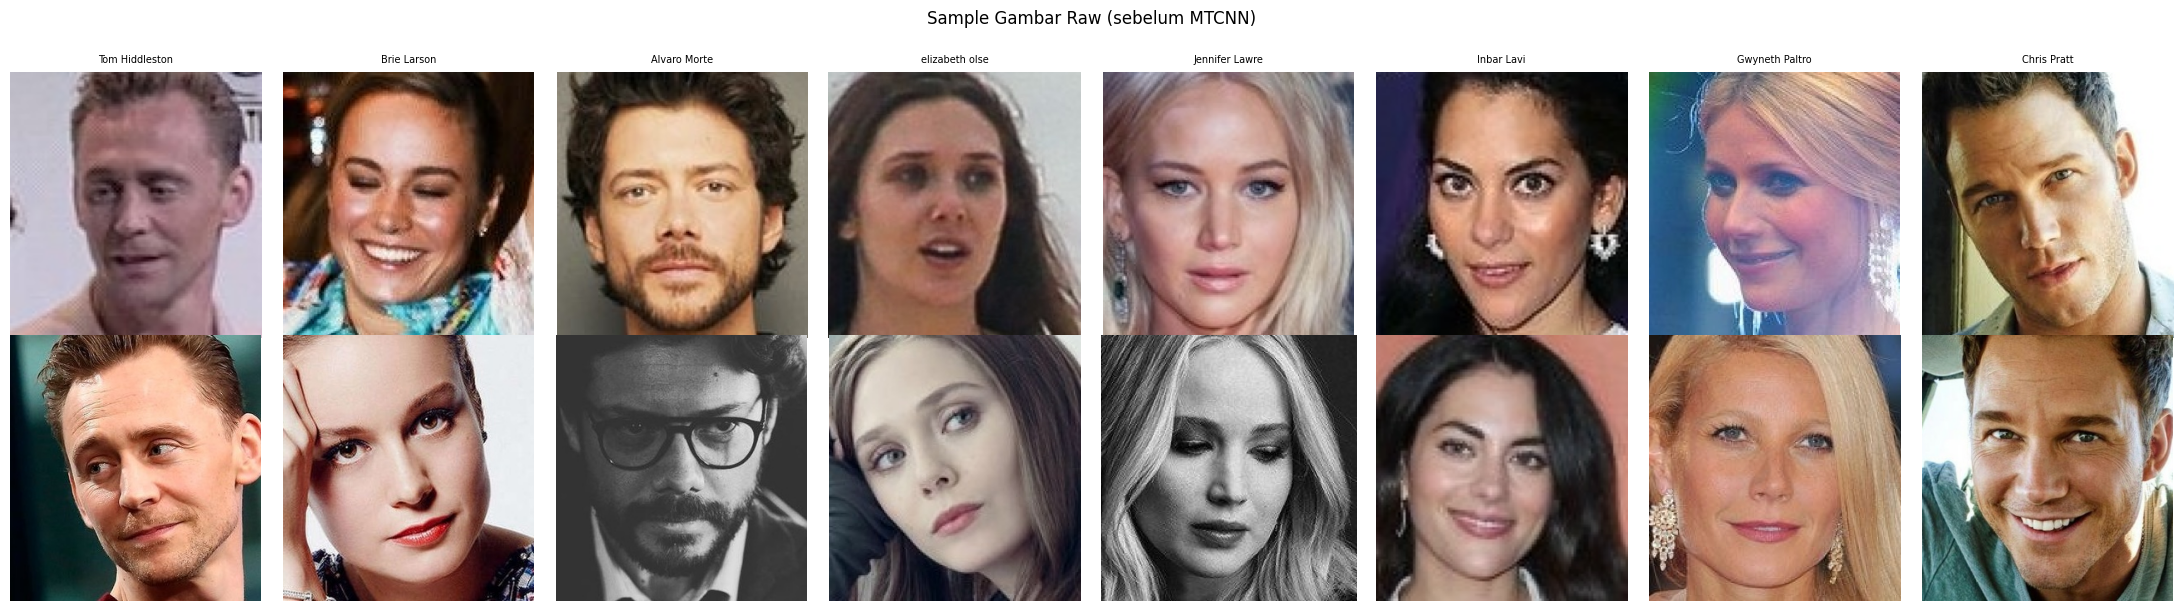

In [8]:
import random
from PIL import Image

cls_dirs = [d for d in dataset_root.iterdir() if d.is_dir()]
samples  = random.sample(cls_dirs, min(8, len(cls_dirs)))

fig, axes = plt.subplots(2, 8, figsize=(22, 6))
for col, cls_dir in enumerate(samples):
    name = cls_dir.name[5:] if cls_dir.name.lower().startswith('pins_') else cls_dir.name
    imgs = [f for f in cls_dir.rglob('*') if f.suffix.lower() in IMG_EXTS]
    random.shuffle(imgs)
    for row in range(2):
        ax = axes[row][col]
        if row < len(imgs):
            try:
                ax.imshow(Image.open(imgs[row]).convert('RGB'))
            except Exception:
                pass
        if row == 0:
            ax.set_title(name[:14], fontsize=7)
        ax.axis('off')
plt.suptitle('Sample Gambar Raw (sebelum MTCNN)', y=1.01)
plt.tight_layout()
plt.show()

# MTCNN Preprocessing

In [ ]:
from src.data.preprocessor import FacePreprocessor

prep = FacePreprocessor(cfg, device)

# force=False → skip jika processed/ sudah terisi
# force=True  → hapus dan proses ulang dari awal
proc_path = prep.run(force=False)

n_proc = sum(1 for _ in proc_path.rglob('*.jpg'))
n_cls  = sum(1 for d in proc_path.iterdir() if d.is_dir())
print(f"Hasil MTCNN: {n_cls} kelas, {n_proc:,} gambar")
print(f"Tersimpan di: {proc_path}")

[12:19:32][INFO] Memulai MTCNN preprocessing: 17534 gambar ...
MTCNN:  41%|████      | 7105/17534 [42:03<1:09:58,  2.48it/s]

# Perbandingan Raw vs Processed

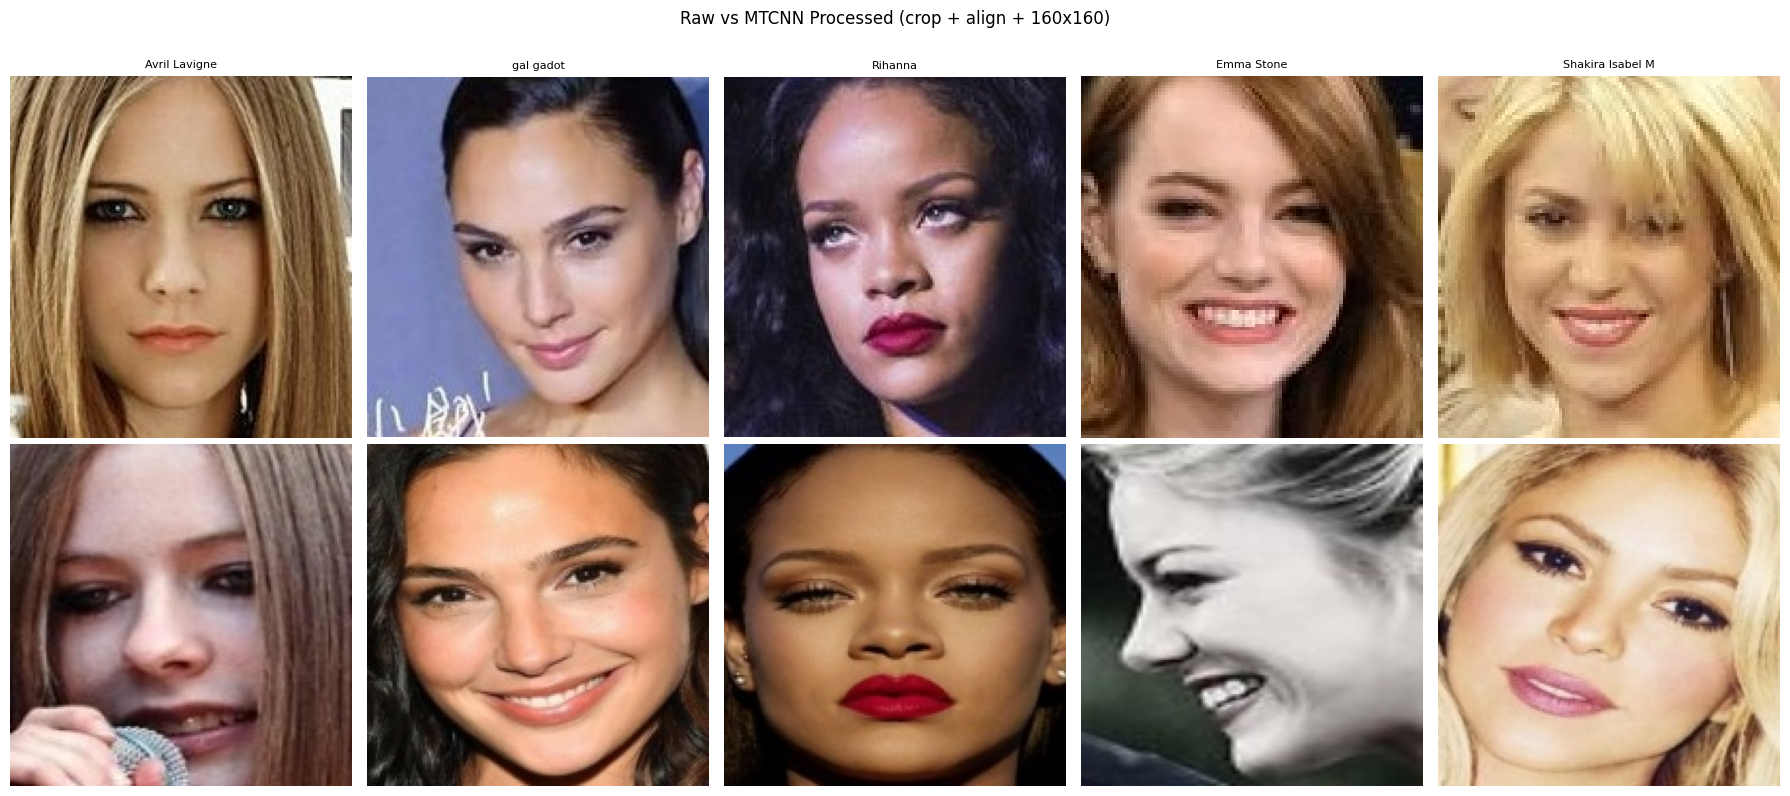

Notebook 01 selesai. Lanjut ke Notebook 02.


In [ ]:
from pathlib import Path
import random
from PIL import Image

proc_root = Path(cfg['data']['processed_dir'])
raw_root  = Path(cfg['data']['dataset_root'])

raw_map = {}
for d in raw_root.iterdir():
    if d.is_dir():
        name = d.name[5:] if d.name.lower().startswith('pins_') else d.name
        raw_map[name] = d

proc_cls     = [d.name for d in proc_root.iterdir() if d.is_dir()]
sample_names = random.sample(proc_cls, min(5, len(proc_cls)))

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes[0][0].set_ylabel('RAW (original)', fontsize=10)
axes[1][0].set_ylabel('MTCNN 160x160', fontsize=10)

for col, cls_name in enumerate(sample_names):
    raw_imgs  = [f for f in raw_map.get(cls_name, Path('.')).rglob('*')
                 if f.suffix.lower() in IMG_EXTS]
    proc_imgs = list((proc_root / cls_name).glob('*.jpg'))
    for row, imgs in enumerate([raw_imgs, proc_imgs]):
        ax = axes[row][col]
        if imgs:
            try:
                ax.imshow(Image.open(random.choice(imgs)).convert('RGB'))
            except Exception:
                pass
        if row == 0:
            ax.set_title(cls_name[:16], fontsize=8)
        ax.axis('off')

plt.suptitle('Raw vs MTCNN Processed (crop + align + 160x160)', y=1.01)
plt.tight_layout()
plt.show()
print("Notebook 01 selesai. Lanjut ke Notebook 02.")